In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('titanic')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/titanic


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [4]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [7]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
train. shape

train. columns

train.isnull().sum()

train["Survived"].value_counts()

train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [11]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [12]:
train.groupby("Survived")["Age"].mean()
train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [13]:
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())

train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
test["Fare"] = test["Fare"].fillna(test["Fare"].median())

In [14]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [15]:
train["Sex"] = train["Sex"].map({"male": 0, "female": 1})
test["Sex"] = test["Sex"].map({"male": 0, "female": 1})
train[["Sex"]].head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [16]:
train["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [17]:
train["Embarked"] = train["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

test["Embarked"] = test["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})
train[["Embarked"]].head()

,Embarked
0,0
1,1
2,0
3,0
4,0


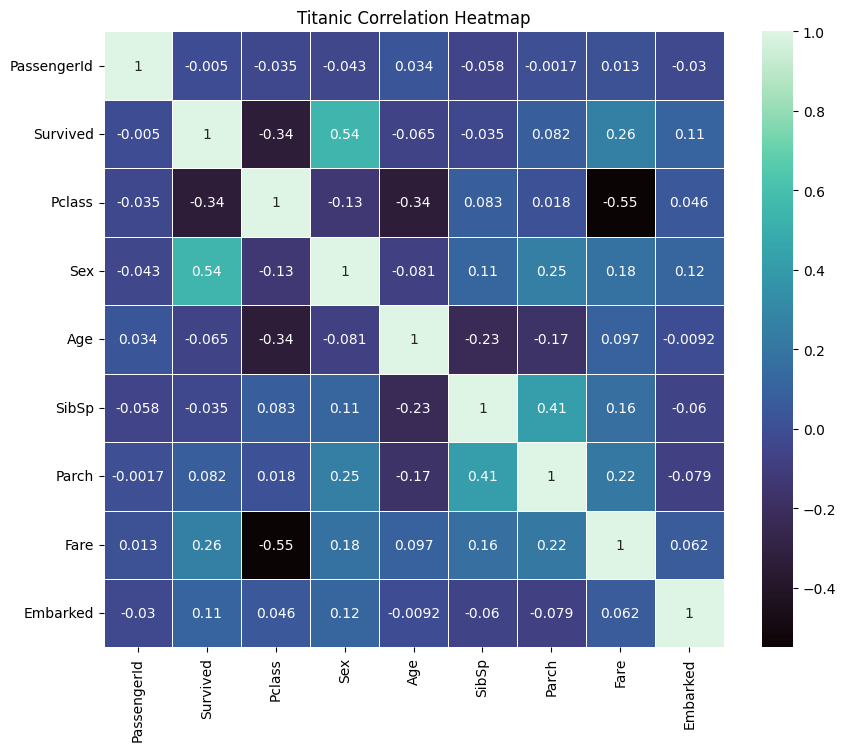

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap="mako",
    linewidths=0.5
)

plt.title("Titanic Correlation Heatmap")
plt.show()

<Axes: >

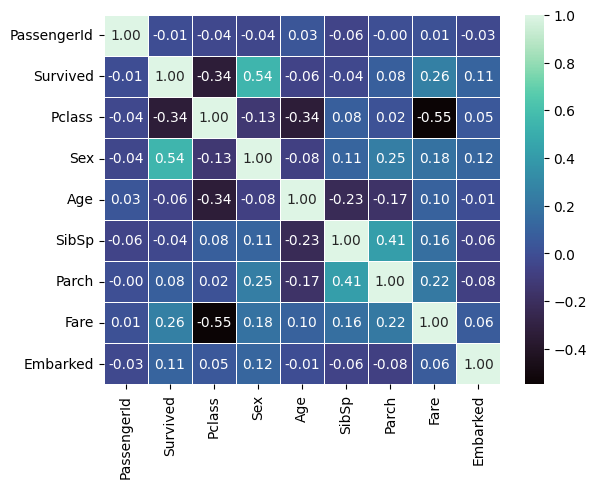

In [19]:
sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    fmt=".2f",      # Show 2 decimal places
    cmap="mako",
    linewidths=0.5
)

In [20]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_indices, test_indices in split.split(
    train,
    train["Survived"]
):
    strat_train_set = train.loc[train_indices]
    strat_test_set = train.loc[test_indices]

In [21]:
print("Training set shape:", strat_train_set.shape)
print("Testing set shape:", strat_test_set.shape)

Training set shape: (712, 12)
Testing set shape: (179, 12)


In [22]:
print("Original Dataset")
print(train["Survived"].value_counts(normalize=True))

print("\nTraining Dataset")
print(strat_train_set["Survived"].value_counts(normalize=True))

print("\nTesting Dataset")
print(strat_test_set["Survived"].value_counts(normalize=True))

Original Dataset
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Training Dataset
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing Dataset
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


In [23]:
strat_train_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,1,3,"Lam, Mr. Ali",0,28.0,0,0,1601,56.4958,NaN,0
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",0,28.0,0,0,239854,0.0000,NaN,0
527,528,0,1,"Farthing, Mr. John",0,28.0,0,0,PC 17483,221.7792,C95,0
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",1,18.0,0,1,392091,9.3500,NaN,0
801,802,1,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",1,31.0,1,1,C.A. 31921,26.2500,NaN,0


In [24]:
strat_test_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
565,566,0,3,"Davies, Mr. Alfred J",0,24.0,2,0,A/4 48871,24.1500,NaN,0
160,161,0,3,"Cribb, Mr. John Hatfield",0,44.0,0,1,371362,16.1000,NaN,0
553,554,1,3,"Leeni, Mr. Fahim (""Philip Zenni"")",0,22.0,0,0,2620,7.2250,NaN,1
860,861,0,3,"Hansen, Mr. Claus Peter",0,41.0,2,0,350026,14.1083,NaN,0
241,242,1,3,"Murphy, Miss. Katherine ""Kate""",1,28.0,1,0,367230,15.5000,NaN,2


In [25]:
strat_train_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         0
dtype: int64

In [26]:
train["Embarked"].head(10)

0    0
1    1
2    0
3    0
4    0
5    2
6    0
7    0
8    0
9    1
Name: Embarked, dtype: int64

In [27]:
train["Embarked"].unique()

array([0, 1, 2])

In [28]:
train["Embarked"].head(10)

train["Embarked"].unique()

strat_train_set["Embarked"].head(10)

strat_train_set["Embarked"].unique()

array([0, 1, 2])

In [29]:
train["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [30]:
train["Embarked"].value_counts(dropna=False)

Embarked
0    646
1    168
2     77
Name: count, dtype: int64

In [31]:
import pandas as pd

# Reload ONLY the Embarked column from the original training data
original_train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

train["Embarked"] = original_train["Embarked"]

# Fill the missing values again
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])

# Convert to numbers ONCE
train["Embarked"] = train["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# Check that it worked
print(train["Embarked"].head())
print("Missing values:", train["Embarked"].isnull().sum())

0    0
1    1
2    0
3    0
4    0
Name: Embarked, dtype: int64
Missing values: 0


In [32]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_indices, test_indices in split.split(train, train["Survived"]):
    strat_train_set = train.loc[train_indices].copy()
    strat_test_set = train.loc[test_indices].copy()

In [33]:
print(strat_train_set.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         0
dtype: int64


In [34]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X_train = strat_train_set[features]
y_train = strat_train_set["Survived"]

X_test = strat_test_set[features]
y_test = strat_test_set["Survived"]

print(X_train.head())
print(y_train.head())

     Pclass  Sex   Age  SibSp  Parch      Fare  Embarked
692       3    0  28.0      0      0   56.4958         0
481       2    0  28.0      0      0    0.0000         0
527       1    0  28.0      0      0  221.7792         0
855       3    1  18.0      0      1    9.3500         0
801       2    1  31.0      1      1   26.2500         0
692    1
481    0
527    0
855    1
801    1
Name: Survived, dtype: int64


In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
predictions = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[96 14]
 [19 50]]


In [39]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

    Feature  Importance
5      Fare    0.274793
1       Sex    0.258877
2       Age    0.249182
0    Pclass    0.090712
3     SibSp    0.050683
4     Parch    0.040519
6  Embarked    0.035234


In [40]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X_full = train[features]
y_full = train["Survived"]

X_kaggle = test[features]

In [41]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_full, y_full)

RandomForestClassifier(random_state=42)

In [42]:
kaggle_predictions = final_model.predict(X_kaggle)

In [43]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0


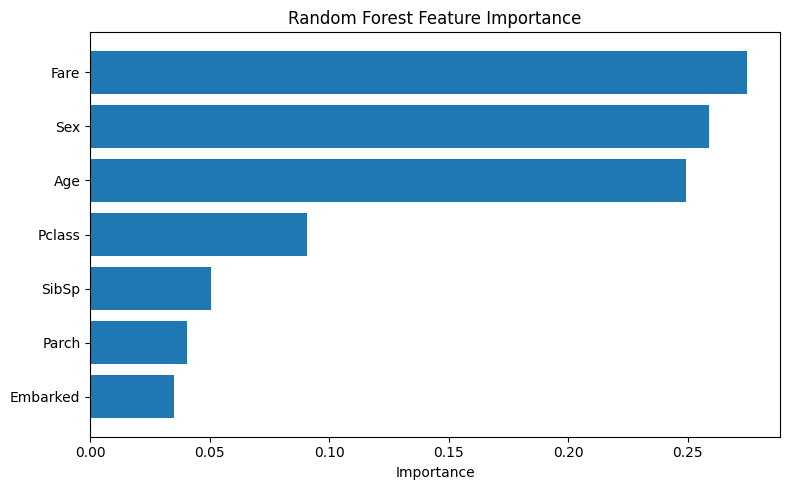

In [44]:
import matplotlib.pyplot as plt

importance = importance.sort_values("Importance", ascending=True)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

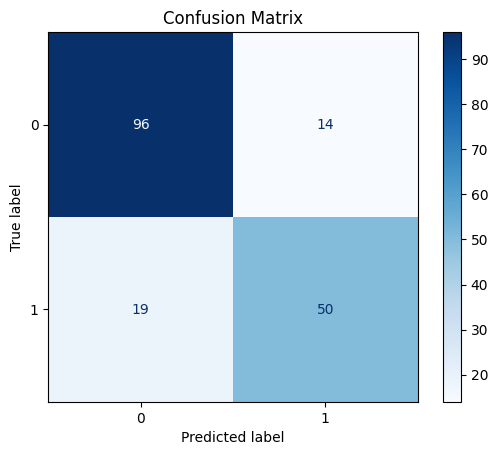

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [46]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

In [47]:
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

In [48]:
train["Title"] = train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
test["Title"] = test["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

In [49]:
print(train["Title"].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [50]:
train["Title"] = train["Title"].replace(["Mlle", "Ms"], "Miss")
train["Title"] = train["Title"].replace("Mme", "Mrs")

test["Title"] = test["Title"].replace(["Mlle", "Ms"], "Miss")
test["Title"] = test["Title"].replace("Mme", "Mrs")

In [51]:
rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don",
    "Dr", "Major", "Rev", "Sir", "Jonkheer", "Dona"
]

train["Title"] = train["Title"].replace(rare_titles, "Rare")
test["Title"] = test["Title"].replace(rare_titles, "Rare")

In [52]:
title_map = {
    "Mr": 0,
    "Miss": 1,
    "Mrs": 2,
    "Master": 3,
    "Rare": 4
}

train["Title"] = train["Title"].map(title_map)
test["Title"] = test["Title"].map(title_map)

train["Title"] = train["Title"].fillna(4)
test["Title"] = test["Title"].fillna(4)

In [53]:
print(train["Title"].value_counts())

Title
0    517
1    185
2    126
3     40
4     23
Name: count, dtype: int64


In [54]:
train["HasCabin"] = train["Cabin"].notnull().astype(int)
test["HasCabin"] = test["Cabin"].notnull().astype(int)


In [55]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "HasCabin"
]

In [56]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, test_idx in split.split(train, train["Survived"]):
    strat_train_set = train.loc[train_idx].copy()
    strat_test_set = train.loc[test_idx].copy()

In [57]:
X_train = strat_train_set[features]
y_train = strat_train_set["Survived"]

X_test = strat_test_set[features]
y_test = strat_test_set["Survived"]

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877
